<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-wiktoriamalinowska/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [ ]:
# wczytanie zbioru danych
titanic = pd.read_csv("/content/titanic.csv")

titanic.shape

(891, 12)

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Wyjaśnienie oznaczeń: SibSp - Sibling or Spouse, Parch - Parent or Children

## Ile osób przeżyło

In [ ]:
titanic.Survived.value_counts()

,count
Survived,
0,549
1,342


549 pasażerów nie przeżyło

In [ ]:
titanic.Sex.value_counts()

,count
Sex,
male,577
female,314


Większość pasażerów jest płci męskiej (zaskakujące).

## Klasa pasażerska

In [ ]:
titanic.Pclass.value_counts()

,count
Pclass,
3,491
1,216
2,184


## Miejsce zaokrętowania

In [ ]:
titanic.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


C = Cherbourg, Q = Queenstown, S = Southampton

## Czy ktoś z rodziny podróżował z pasażerem

In [ ]:
titanic.SibSp.value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


Większość pasażerów (608) podróżowała bez rodzeństwa lub partnerów.

In [ ]:
titanic.Parch.value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


Ponownie, większość pasażerów (678) nie podróżowało z rodzicem lub z dziećmi.

## Przekształcenie danych

In [ ]:
# MIEJSCE NA TWÓJ KOD

## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [ ]:
titanic['Age'] = titanic.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [ ]:
titanic.Embarked.isnull().value_counts()

,count
Embarked,
False,889
True,2


Ponieważ brakuje tylko 2 danych w kolumnie dot. zaokrętowania, zastąpimy NaNy literą 'S' (Southampton port), ponieważ to on najczęściej wystąpił w danych.

In [ ]:
titanic['Embarked'] = titanic.Embarked.transform(lambda x: x.fillna('S'))

In [ ]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [ ]:
titanic.Cabin.isnull().value_counts()

,count
Cabin,
True,687
False,204


Zdecydowanie większość danych dot. kabin nie istnieje, więc zamienimy sobie to na kolumnę typu boolean, która nam mówi czy pasażer miał kabinę czy nie. Poza tym, konkretna nazwa kabiny nie jest za bardzo potrzebna w predykowaniu czy ktoś miał szansę na przeżycie czy nie.


In [ ]:
titanic['Cabin'] = np.where(titanic['Cabin'].isna(), 0, 1)

In [ ]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [ ]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

## Correlation matrix

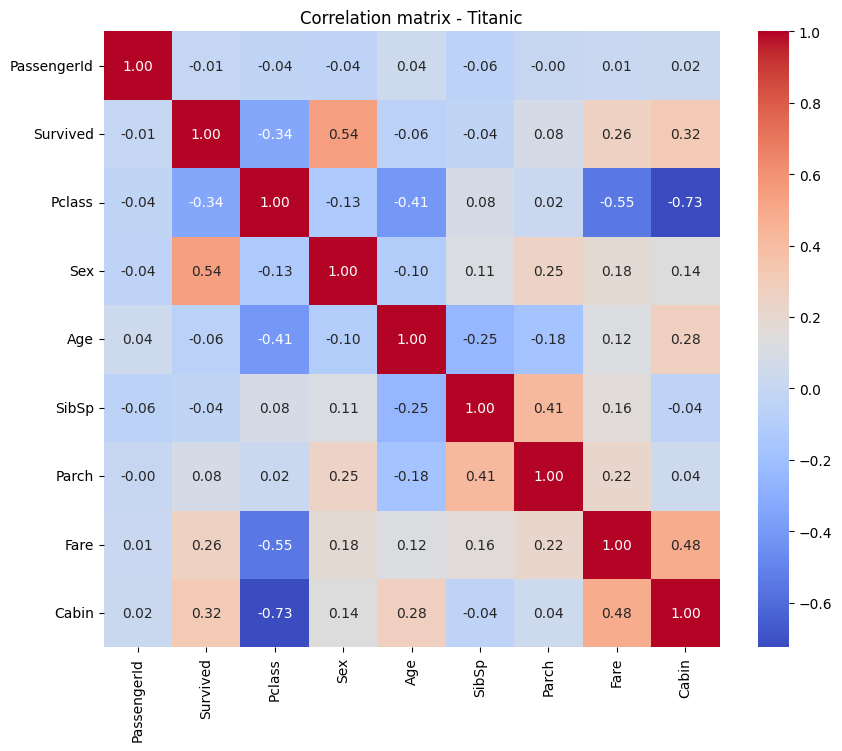

In [ ]:
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})

numeric_cols = titanic.select_dtypes(include=['number'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True
            )

plt.title('Correlation matrix - Titanic')
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

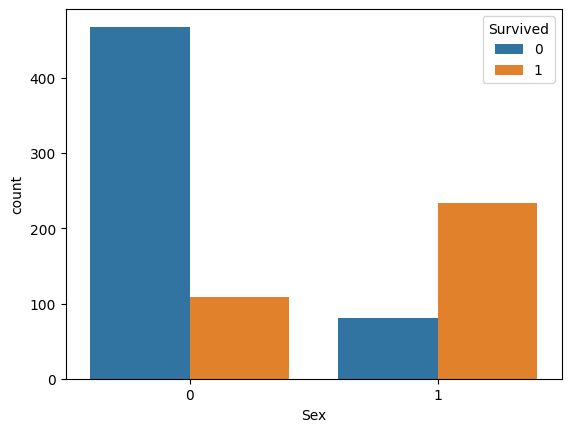

In [ ]:
sns.countplot(
    data=titanic,
    x=titanic.Sex,
    hue=titanic.Survived
)

<Axes: xlabel='Pclass', ylabel='count'>

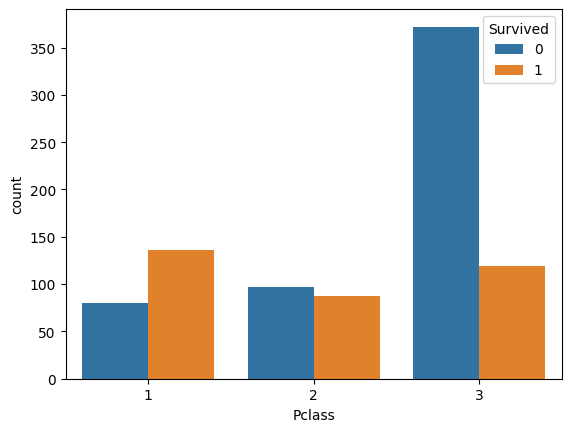

In [ ]:
sns.countplot(
    data=titanic,
    x=titanic.Pclass,
    hue=titanic.Survived
)

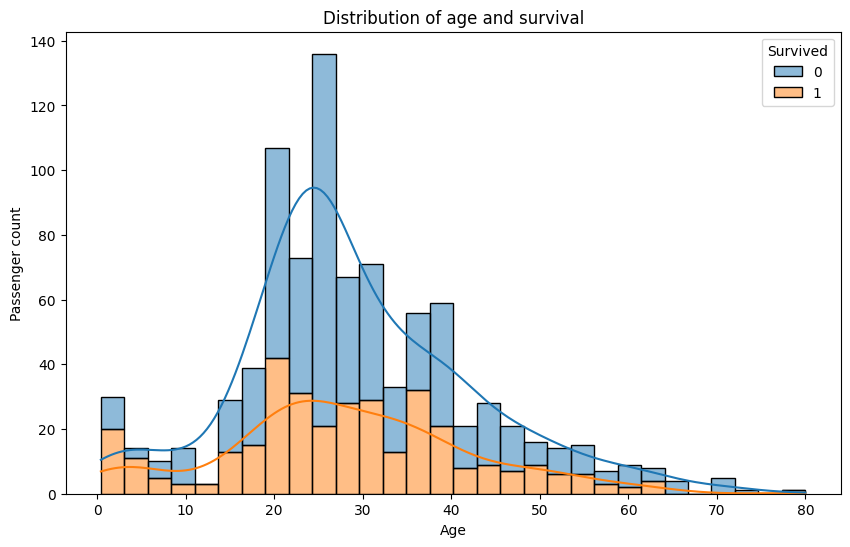

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=titanic,
    x='Age',
    hue='Survived',
    multiple='stack',
    bins=30,
    kde=True
)
plt.title('Distribution of age and survival')
plt.xlabel('Age')
plt.ylabel('Passenger count')
plt.show()

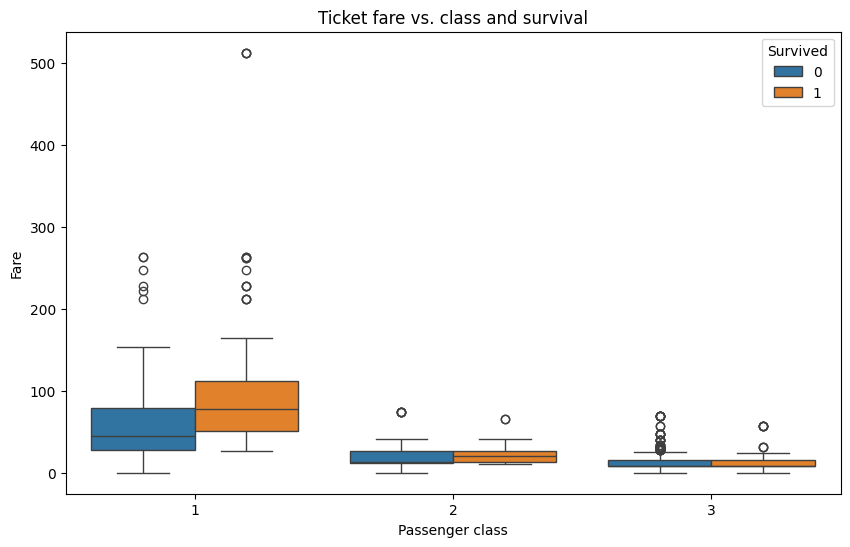

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=titanic,
    x='Pclass',
    y='Fare',
    hue='Survived'
)
plt.title('Ticket fare vs. class and survival')
plt.xlabel('Passenger class')
plt.ylabel('Fare')
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

Większe prawdopodobieństwo na przeżycie jest kiedy jesteś kobietą, najlepiej z pierwszej klasy, pomiędzy 20 a 40. Bycie dzieckiem też pomaga w przeżyciu. Ku mojemu zdziwieniu przeżyło znacznie mniej mężczyzn niż kobiet, a to oni stanowili większość na statku. To, że osoby które zapłaciły 500 dolców za bilet przeżyły wcale mnie nie dziwi.

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [3]:
spotify = pd.read_csv("/content/spotify.csv", index_col=0)

spotify.shape

(114000, 20)

In [4]:
spotify.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


| Kolumna | Opis |
|---------|------|
| track_id | Identyfikator Spotify dla utworu. |
| artists | Nazwy artystów wykonujących utwór. Jeśli jest ich więcej, oddzielone są znakiem średnika (;). |
| album_name | Nazwa albumu, na którym znajduje się utwór. |
| track_name | Nazwa utworu. |
| popularity | Popularność utworu w skali od 0 do 100 (100 to największa). Obliczana algorytmicznie na podstawie liczby i "świeżości" odtworzeń. |
| duration_ms | Długość utworu w milisekundach. |
| explicit | Informacja, czy utwór zawiera niecenzuralne słowa (true = tak; false = nie LUB nieznane). |
| danceability | "Taneczność" określająca, jak bardzo utwór nadaje się do tańca (na podstawie tempa, rytmu itp.). Wartość 0.0 to utwór najmniej taneczny, a 1.0 – najbardziej. |
| energy | Energia w skali od 0.0 do 1.0. Utwory o wysokiej energii są szybkie i głośne (np. death metal), a o niskiej – spokojniejsze (np. muzyka klasyczna). |
| key | Tonacja utworu. Liczby odpowiadają standardowej notacji (np. 0 = C, 1 = C♯/D♭, 2 = D itd.). Wartość -1 oznacza brak wykrytej tonacji. |
| loudness | Całkowita głośność utworu wyrażona w decybelach (dB). |
| mode | Skala utworu. Skala durowa (major) to 1, a molowa (minor) to 0. |
| speechiness | Obecność słów mówionych. Powyżej 0.66 to mowa (np. audiobooki), 0.33-0.66 to mieszanka muzyki i mowy (np. rap), a poniżej 0.33 to standardowa muzyka. |
| acousticness | Poziom pewności (od 0.0 do 1.0), czy utwór jest akustyczny. 1.0 to wysoka pewność. |
| instrumentalness | Przewiduje brak wokalu. Im bliżej 1.0, tym większe prawdopodobieństwo, że utwór to czysty instrumental (rap to wokal, ale dźwięki typu "ooh" to instrumental). |
| liveness | Wykrywa obecność publiczności. Wartości powyżej 0.8 to duże prawdopodobieństwo, że utwór był nagrywany na żywo. |
| valence | Pozytywny ładunek emocjonalny (od 0.0 do 1.0). Wysoka walencja to brzmienia radosne, a niska – smutne lub gniewne. |
| tempo | Szacowane tempo utworu w uderzeniach na minutę (BPM). |
| time_signature | Szacowane metrum (liczba uderzeń w takcie). Przyjmuje wartości od 3 do 7 (czyli metrum od 3/4 do 7/4). |
| track_genre | Gatunek muzyczny, do którego należy utwór. |

In [5]:
spotify.artists.value_counts()

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
...,...
Hillsong Worship;TAYA;David Ware,1
for KING & COUNTRY;Andy Mineo,1
Bethel Music;Francesca Battistelli,1


Top 3 artyści: The Beatles, George Jones, Stevie Wonder.

In [6]:
spotify.track_genre.value_counts()

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
trance,1000
trip-hop,1000


## Przekształcenia i filtracja danych

In [7]:
spotify.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [8]:
spotify[spotify.artists.isnull()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


cudownie, wszystkie brakujące wartości znajdują się w dokładnie jednym wierszu.

In [13]:
spotify = spotify.dropna()

In [14]:
assert spotify.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

Ten zbiór danych ma założenie, że bierzemy 1000 najpopularniejszych piosenek z każdego gatunku, co powoduje nam, że czyjaś piosenka może występować kilka razy w datasetcie.

In [9]:
duplikaty = spotify[spotify.duplicated(subset=['track_id'], keep=False)]
podglad_duplikatow = duplikaty.sort_values(by='track_id')[['track_id', 'track_name', 'artists', 'track_genre']]

podglad_duplikatow.head(10)

,track_id,track_name,artists,track_genre
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo


Bingo. Są duplikaty.

In [11]:
spotify.dropna(inplace=True)
spotify.drop_duplicates(subset=['track_id'], inplace=True)

spotify.shape

(89740, 20)

Sprawdźmy jak zmieniła się ilość piosenek pod każdy gatunek.

In [15]:
spotify.track_genre.value_counts()

,count
track_genre,
acoustic,1000
afrobeat,999
alt-rock,999
ambient,999
cantopop,999
...,...
metal,232
punk,226
house,210


Z ciekawości powtórzmy najpopularniejszych wykonawców.

In [12]:
spotify.artists.value_counts()

,count
artists,
George Jones,260
my little airport,171
The Beatles,149
BTS,143
Håkan Hellström,141
...,...
Thirteen;Rudy Nugraha Putra;Raynard Rahardja;Jodi Melani;Ardiansyah Darmawangsa,1
Crown The Empire,1
Talib Kweli,1


## Wizualizacje

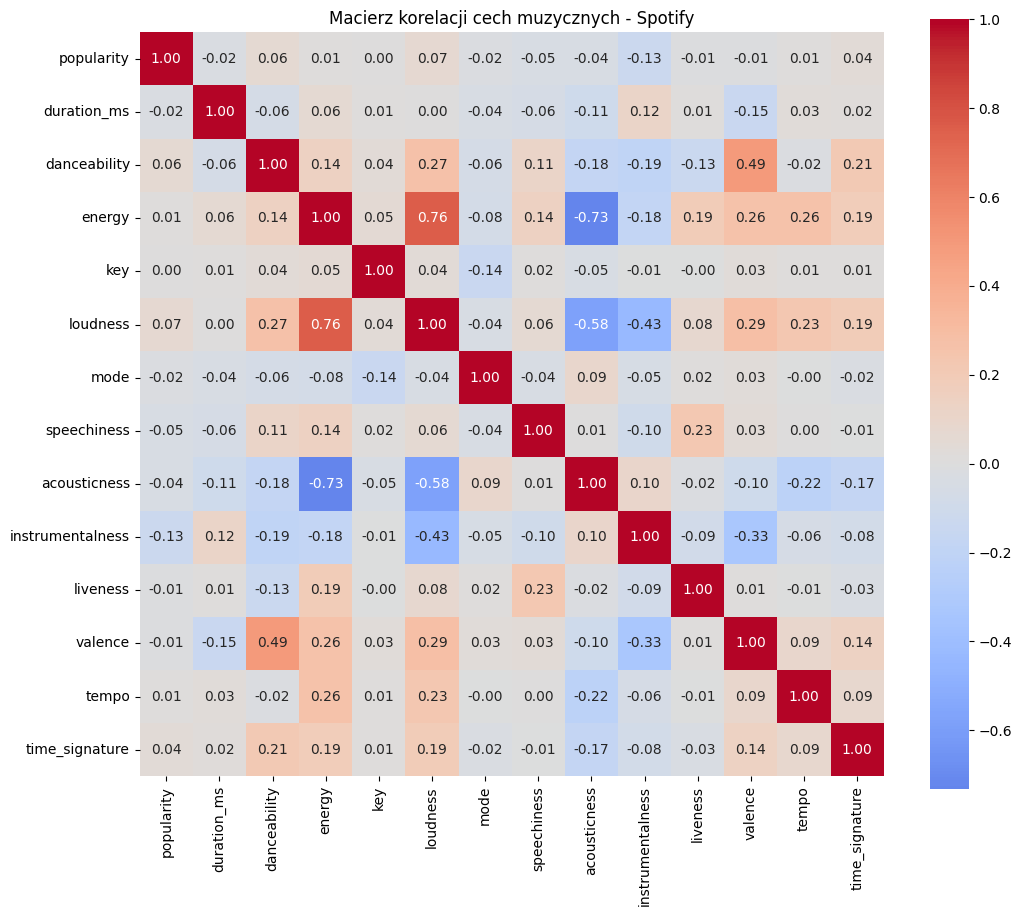

In [18]:
plt.figure(figsize=(12, 10))
numeric_cols = spotify.select_dtypes(include=['number'])

corr_matrix_spotify = numeric_cols.corr()

sns.heatmap(
    corr_matrix_spotify,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True
)
plt.title('Macierz korelacji cech muzycznych - Spotify')
plt.show()

Mamy poztywną korelację pomiędzy energią a głośnością, negatywną pomiędzy energią a akustyką utworu. Dodatkowo jest dosyć wysoka relacja między tanecznością utworu a jego pozytywnym ładunkiem emocjonalnym.

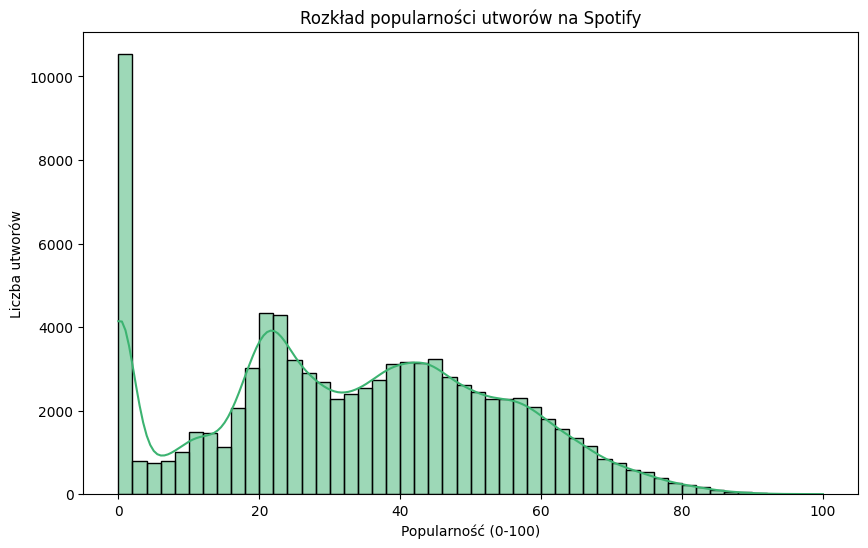

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=spotify,
    x='popularity',
    bins=50,
    kde=True,
    color='mediumseagreen'
)
plt.title('Rozkład popularności utworów na Spotify')
plt.xlabel('Popularność (0-100)')
plt.ylabel('Liczba utworów')
plt.show()

Zdecydowanie więcej jest utworów niszowych.

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [24]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [26]:
def get_emotion(row):
    k = row['key']
    m = row['mode']

    key_str = key_map[k]
    mode_str = 'Major' if m == 1 else 'Minor'

    return emotion_map.get((key_str, mode_str), 'Unknown')

spotify['emotion'] = spotify.apply(get_emotion, axis=1)

spotify.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,emotion
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Melancholic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Joyful
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Happy
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Happy
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Triumphant


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
# MIEJSCE NA TWÓJ KOD

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [ ]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [ ]:
# przykładowe funkcje

def dataframe_xy(df):
    raise NotImplementedError()
    return X, y

# normalize to [0,1] range
def normalize(X):
    raise NotImplementedError()

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    raise NotImplementedError()

# remove outliers
def remove_outliers(X, y):
    raise NotImplementedError()
